In [1]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9683 sha256=b8c041521725b65a3eaf2cf57cfe4ae00dd9e002f5d3e8fff67c39977ce3d97b
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [2]:
!pip install timm==0.4.5 --force-reinstall --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 1.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: timm
    Found existing installation: timm 1.0.26
    Uninstalling timm-1.0.26:
      Successfully uninstalled timm-1.0.26


In [3]:
# mean value for dataset = -0.005844594683952334
# std value for the dataset = 0.12848169072607715

In [4]:
# -*- coding: utf-8 -*-
# @Time    : 6/10/21 5:04 PM
# @Author  : Yuan Gong
# @Affiliation  : Massachusetts Institute of Technology
# @Email   : yuangong@mit.edu
# @File    : ast_models.py

import torch
import torch.nn as nn
from torch.cuda.amp import autocast
import os
import wget
import timm
from timm.models.layers import to_2tuple,trunc_normal_

# override the timm package to relax the input shape constraint.
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()

        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        num_patches = (img_size[1] // patch_size[1]) * (img_size[0] // patch_size[0])
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = num_patches

        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

class ASTModel(nn.Module):
    """
    The AST model.
    :param label_dim: the label dimension, i.e., the number of total classes, it is 527 for AudioSet, 50 for ESC-50, and 35 for speechcommands v2-35
    :param fstride: the stride of patch spliting on the frequency dimension, for 16*16 patchs, fstride=16 means no overlap, fstride=10 means overlap of 6
    :param tstride: the stride of patch spliting on the time dimension, for 16*16 patchs, tstride=16 means no overlap, tstride=10 means overlap of 6
    :param input_fdim: the number of frequency bins of the input spectrogram
    :param input_tdim: the number of time frames of the input spectrogram
    :param imagenet_pretrain: if use ImageNet pretrained model
    :param audioset_pretrain: if use full AudioSet and ImageNet pretrained model
    :param model_size: the model size of AST, should be in [tiny224, small224, base224, base384], base224 and base 384 are same model, but are trained differently during ImageNet pretraining.
    """
    def __init__(self, label_dim=527, fstride=10, tstride=10, input_fdim=128, input_tdim=1024, imagenet_pretrain=True, audioset_pretrain=False, model_size='base384', verbose=True):

        super(ASTModel, self).__init__()
        assert timm.__version__ == '0.4.5', 'Please use timm == 0.4.5, the code might not be compatible with newer versions.'

        if verbose == True:
            print('---------------AST Model Summary---------------')
            print('ImageNet pretraining: {:s}, AudioSet pretraining: {:s}'.format(str(imagenet_pretrain),str(audioset_pretrain)))
        # override timm input shape restriction
        timm.models.vision_transformer.PatchEmbed = PatchEmbed

        # if AudioSet pretraining is not used (but ImageNet pretraining may still apply)
        if audioset_pretrain == False:
            if model_size == 'tiny224':
                self.v = timm.create_model('vit_deit_tiny_distilled_patch16_224', pretrained=imagenet_pretrain)
            elif model_size == 'small224':
                self.v = timm.create_model('vit_deit_small_distilled_patch16_224', pretrained=imagenet_pretrain)
            elif model_size == 'base224':
                self.v = timm.create_model('vit_deit_base_distilled_patch16_224', pretrained=imagenet_pretrain)
            elif model_size == 'base384':
                self.v = timm.create_model('vit_deit_base_distilled_patch16_384', pretrained=imagenet_pretrain)
            else:
                raise Exception('Model size must be one of tiny224, small224, base224, base384.')
            self.original_num_patches = self.v.patch_embed.num_patches
            self.oringal_hw = int(self.original_num_patches ** 0.5)
            self.original_embedding_dim = self.v.pos_embed.shape[2]
            self.mlp_head = nn.Sequential(nn.LayerNorm(self.original_embedding_dim), nn.Linear(self.original_embedding_dim, label_dim))

            # automatcially get the intermediate shape
            f_dim, t_dim = self.get_shape(fstride, tstride, input_fdim, input_tdim)
            num_patches = f_dim * t_dim
            self.v.patch_embed.num_patches = num_patches
            if verbose == True:
                print('frequncey stride={:d}, time stride={:d}'.format(fstride, tstride))
                print('number of patches={:d}'.format(num_patches))

            # the linear projection layer
            new_proj = torch.nn.Conv2d(1, self.original_embedding_dim, kernel_size=(16, 16), stride=(fstride, tstride))
            if imagenet_pretrain == True:
                new_proj.weight = torch.nn.Parameter(torch.sum(self.v.patch_embed.proj.weight, dim=1).unsqueeze(1))
                new_proj.bias = self.v.patch_embed.proj.bias
            self.v.patch_embed.proj = new_proj

            # the positional embedding
            if imagenet_pretrain == True:
                # get the positional embedding from deit model, skip the first two tokens (cls token and distillation token), reshape it to original 2D shape (24*24).
                new_pos_embed = self.v.pos_embed[:, 2:, :].detach().reshape(1, self.original_num_patches, self.original_embedding_dim).transpose(1, 2).reshape(1, self.original_embedding_dim, self.oringal_hw, self.oringal_hw)
                # cut (from middle) or interpolate the second dimension of the positional embedding
                if t_dim <= self.oringal_hw:
                    new_pos_embed = new_pos_embed[:, :, :, int(self.oringal_hw / 2) - int(t_dim / 2): int(self.oringal_hw / 2) - int(t_dim / 2) + t_dim]
                else:
                    new_pos_embed = torch.nn.functional.interpolate(new_pos_embed, size=(self.oringal_hw, t_dim), mode='bilinear')
                # cut (from middle) or interpolate the first dimension of the positional embedding
                if f_dim <= self.oringal_hw:
                    new_pos_embed = new_pos_embed[:, :, int(self.oringal_hw / 2) - int(f_dim / 2): int(self.oringal_hw / 2) - int(f_dim / 2) + f_dim, :]
                else:
                    new_pos_embed = torch.nn.functional.interpolate(new_pos_embed, size=(f_dim, t_dim), mode='bilinear')
                # flatten the positional embedding
                new_pos_embed = new_pos_embed.reshape(1, self.original_embedding_dim, num_patches).transpose(1,2)
                # concatenate the above positional embedding with the cls token and distillation token of the deit model.
                self.v.pos_embed = nn.Parameter(torch.cat([self.v.pos_embed[:, :2, :].detach(), new_pos_embed], dim=1))
            else:
                # if not use imagenet pretrained model, just randomly initialize a learnable positional embedding
                # TODO can use sinusoidal positional embedding instead
                new_pos_embed = nn.Parameter(torch.zeros(1, self.v.patch_embed.num_patches + 2, self.original_embedding_dim))
                self.v.pos_embed = new_pos_embed
                trunc_normal_(self.v.pos_embed, std=.02)

        # now load a model that is pretrained on both ImageNet and AudioSet
        elif audioset_pretrain == True:
            if audioset_pretrain == True and imagenet_pretrain == False:
                raise ValueError('currently model pretrained on only audioset is not supported, please set imagenet_pretrain = True to use audioset pretrained model.')
            if model_size != 'base384':
                raise ValueError('currently only has base384 AudioSet pretrained model.')
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            if os.path.exists('/kaggle/input/models/a3amat02/audioset-pretrained-ast/pytorch/default/1/audioset_10_10_0.4593.pth') == False:
                # this model performs 0.4593 mAP on the audioset eval set
                audioset_mdl_url = 'https://www.dropbox.com/s/cv4knew8mvbrnvq/audioset_0.4593.pth?dl=1'
                wget.download(audioset_mdl_url, out='/kaggle/input/models/a3amat02/audioset-pretrained-ast/pytorch/default/1/audioset_10_10_0.4593.pth')
            sd = torch.load('/kaggle/input/models/a3amat02/audioset-pretrained-ast/pytorch/default/1/audioset_10_10_0.4593.pth', map_location=device)
            audio_model = ASTModel(label_dim=527, fstride=10, tstride=10, input_fdim=128, input_tdim=1024, imagenet_pretrain=False, audioset_pretrain=False, model_size='base384', verbose=False)
            audio_model = torch.nn.DataParallel(audio_model)
            audio_model.load_state_dict(sd, strict=False)
            self.v = audio_model.module.v
            self.original_embedding_dim = self.v.pos_embed.shape[2]
            self.mlp_head = nn.Sequential(nn.LayerNorm(self.original_embedding_dim), nn.Linear(self.original_embedding_dim, label_dim))

            f_dim, t_dim = self.get_shape(fstride, tstride, input_fdim, input_tdim)
            num_patches = f_dim * t_dim
            self.v.patch_embed.num_patches = num_patches
            if verbose == True:
                print('frequncey stride={:d}, time stride={:d}'.format(fstride, tstride))
                print('number of patches={:d}'.format(num_patches))

            new_pos_embed = self.v.pos_embed[:, 2:, :].detach().reshape(1, 1212, 768).transpose(1, 2).reshape(1, 768, 12, 101)
            # if the input sequence length is larger than the original audioset (10s), then cut the positional embedding
            if t_dim < 101:
                new_pos_embed = new_pos_embed[:, :, :, 50 - int(t_dim/2): 50 - int(t_dim/2) + t_dim]
            # otherwise interpolate
            else:
                new_pos_embed = torch.nn.functional.interpolate(new_pos_embed, size=(12, t_dim), mode='bilinear')
            if f_dim < 12:
                new_pos_embed = new_pos_embed[:, :, 6 - int(f_dim/2): 6 - int(f_dim/2) + f_dim, :]
            # otherwise interpolate
            elif f_dim > 12:
                new_pos_embed = torch.nn.functional.interpolate(new_pos_embed, size=(f_dim, t_dim), mode='bilinear')
            new_pos_embed = new_pos_embed.reshape(1, 768, num_patches).transpose(1, 2)
            self.v.pos_embed = nn.Parameter(torch.cat([self.v.pos_embed[:, :2, :].detach(), new_pos_embed], dim=1))

    def get_shape(self, fstride, tstride, input_fdim=128, input_tdim=1024):
        test_input = torch.randn(1, 1, input_fdim, input_tdim)
        test_proj = nn.Conv2d(1, self.original_embedding_dim, kernel_size=(16, 16), stride=(fstride, tstride))
        test_out = test_proj(test_input)
        f_dim = test_out.shape[2]
        t_dim = test_out.shape[3]
        return f_dim, t_dim

    @autocast()
    def forward(self, x):
        """
        :param x: the input spectrogram, expected shape: (batch_size, time_frame_num, frequency_bins), e.g., (12, 1024, 128)
        :return: prediction
        """
        # expect input x = (batch_size, time_frame_num, frequency_bins), e.g., (12, 1024, 128)
        x = x.unsqueeze(1)
        x = x.transpose(2, 3)

        B = x.shape[0]
        x = self.v.patch_embed(x)
        cls_tokens = self.v.cls_token.expand(B, -1, -1)
        dist_token = self.v.dist_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, dist_token, x), dim=1)
        x = x + self.v.pos_embed
        x = self.v.pos_drop(x)
        for blk in self.v.blocks:
            x = blk(x)
        x = self.v.norm(x)
        x = (x[:, 0] + x[:, 1]) / 2

        x = self.mlp_head(x)
        return x

/tmp/ipykernel_58/3726344241.py:163: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast()


In [5]:
import csv
import json
import torchaudio
import numpy as np
import pandas as pd
import os
import torch
import torch.nn.functional
from torch.utils.data import Dataset
import random

In [6]:
def create_df(path):
    dd = {"audios": [], "labels": []}
    for i in os.listdir(path):
        img_dir = os.path.join(path, i)
        dirs = os.listdir(img_dir)
        index = 0
        for j in dirs:
            dd["audios"] += [os.path.join(img_dir, j)]
            dd["labels"] += [i]
            index += 1
            if index == 2000:
                break

    return pd.DataFrame(dd)

neg = create_df("/kaggle/input/datasets/a3amat02/infant-cry-detection-dataset/negative")
pos = create_df("/kaggle/input/datasets/a3amat02/infant-cry-detection-dataset/positive")
df = pd.concat([pos, neg])

index_label = {0: "negative", 1: "positive"}
label_index = {"negative": 0, "positive": 1}

df["labels"] = df["labels"].map(label_index)

In [7]:
df.shape

(4000, 2)

In [8]:
def make_index_dict(label_csv):
    index_lookup = {}
    with open(label_csv, 'r') as f:
        csv_reader = csv.DictReader(f)
        line_count = 0
        for row in csv_reader:
            index_lookup[row['mid']] = row['index']
            line_count += 1
    return index_lookup

def make_name_dict(label_csv):
    name_lookup = {}
    with open(label_csv, 'r') as f:
        csv_reader = csv.DictReader(f)
        line_count = 0
        for row in csv_reader:
            name_lookup[row['index']] = row['display_name']
            line_count += 1
    return name_lookup

def lookup_list(index_list, label_csv):
    label_list = []
    table = make_name_dict(label_csv)
    for item in index_list:
        label_list.append(table[item])
    return label_list

def preemphasis(signal,coeff=0.97):
    """perform preemphasis on the input signal.

    :param signal: The signal to filter.
    :param coeff: The preemphasis coefficient. 0 is none, default 0.97.
    :returns: the filtered signal.
    """
    return np.append(signal[0],signal[1:]-coeff*signal[:-1])

class AudiosetDataset(Dataset):
    def __init__(self, df, audio_conf, label_csv=None):
        """
        Dataset that manages audio recordings
        :param audio_conf: Dictionary containing the audio loading and preprocessing settings
        :param dataset_json_file
        """

        self.data = df
        self.audio_conf = audio_conf
        self.melbins = self.audio_conf.get('num_mel_bins')
        self.freqm = self.audio_conf.get('freqm')
        self.timem = self.audio_conf.get('timem')
        self.mixup = self.audio_conf.get('mixup')
        # dataset spectrogram mean and std, used to normalize the input
        self.norm_mean = self.audio_conf.get('mean')
        self.norm_std = self.audio_conf.get('std')
        # skip_norm is a flag that if you want to skip normalization to compute the normalization stats using src/get_norm_stats.py, if Ture, input normalization will be skipped for correctly calculating the stats.
        # set it as True ONLY when you are getting the normalization stats.
        self.skip_norm = self.audio_conf.get('skip_norm') if self.audio_conf.get('skip_norm') else False
        # if add noise for data augmentation
        self.noise = self.audio_conf.get('noise')

    def _wav2fbank(self, filename, filename2=None):
        # mixup
        if filename2 == None:
            waveform, sr = torchaudio.load(filename)
            waveform = waveform - waveform.mean()
        # mixup
        else:
            waveform1, sr = torchaudio.load(filename)
            waveform2, _ = torchaudio.load(filename2)

            waveform1 = waveform1 - waveform1.mean()
            waveform2 = waveform2 - waveform2.mean()

            if waveform1.shape[1] != waveform2.shape[1]:
                if waveform1.shape[1] > waveform2.shape[1]:
                    # padding
                    temp_wav = torch.zeros(1, waveform1.shape[1])
                    temp_wav[0, 0:waveform2.shape[1]] = waveform2
                    waveform2 = temp_wav
                else:
                    # cutting
                    waveform2 = waveform2[0, 0:waveform1.shape[1]]

            # sample lambda from uniform distribution
            #mix_lambda = random.random()
            # sample lambda from beta distribtion
            mix_lambda = np.random.beta(10, 10)

            mix_waveform = mix_lambda * waveform1 + (1 - mix_lambda) * waveform2
            waveform = mix_waveform - mix_waveform.mean()

        fbank = torchaudio.compliance.kaldi.fbank(waveform, htk_compat=True, sample_frequency=sr, use_energy=False,
                                                  window_type='hanning', num_mel_bins=self.melbins, dither=0.0, frame_shift=10)

        target_length = self.audio_conf.get('target_length')
        n_frames = fbank.shape[0]

        p = target_length - n_frames

        # cut and pad
        if p > 0:
            m = torch.nn.ZeroPad2d((0, 0, 0, p))
            fbank = m(fbank)
        elif p < 0:
            fbank = fbank[0:target_length, :]

        if filename2 == None:
            return fbank, 0
        else:
            return fbank, mix_lambda

    def __getitem__(self, index):
        """
        returns: image, audio, nframes
        where image is a FloatTensor of size (3, H, W)
        audio is a FloatTensor of size (N_freq, N_frames) for spectrogram, or (N_frames) for waveform
        nframes is an integer
        """

        file_audio = self.data[index, 0]

        fbank, mix_lambda = self._wav2fbank(file_audio)

        # SpecAug, not do for eval set
        freqm = torchaudio.transforms.FrequencyMasking(self.freqm)
        timem = torchaudio.transforms.TimeMasking(self.timem)
        fbank = torch.transpose(fbank, 0, 1)
        # this is just to satisfy new torchaudio version, which only accept [1, freq, time]
        fbank = fbank.unsqueeze(0)
        if self.freqm != 0:
            fbank = freqm(fbank)
        if self.timem != 0:
            fbank = timem(fbank)
        # squeeze it back, it is just a trick to satisfy new torchaudio version
        fbank = fbank.squeeze(0)
        fbank = torch.transpose(fbank, 0, 1)

        # normalize the input for both training and test
        if not self.skip_norm:
            fbank = (fbank - self.norm_mean) / (self.norm_std * 2)
        # skip normalization the input if you are trying to get the normalization stats.
        else:
            pass

        if self.noise == True:
            fbank = fbank + torch.rand(fbank.shape[0], fbank.shape[1]) * np.random.rand() / 10
            fbank = torch.roll(fbank, np.random.randint(-10, 10), 0)

        mix_ratio = min(mix_lambda, 1-mix_lambda) / max(mix_lambda, 1-mix_lambda)

        # the output fbank shape is [time_frame_num, frequency_bins], e.g., [1024, 128]
        return fbank, self.data[index, 1]

    def __len__(self):
        return len(self.data)


audio_conf = {'num_mel_bins': 128, 'target_length': 1024, 'freqm': 24, 'timem': 192, 'mixup': 0.5, 'skip_norm': False, 'mode': 'train', 'dataset': 'audioset', 'noise': False,
             'mean': -0.005844594683952334, 'std': 0.12848169072607715}

In [9]:
import warnings
warnings.filterwarnings("ignore")

import torchaudio

import IPython

from torchaudio import transforms

from torch.utils.data import Dataset, DataLoader
# from torchaudio.utils import download_asset

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import seaborn as sns

from copy import deepcopy

import torch.nn.functional as F
import math

import random

EPOCHS = 10
STEP = 10
LR = 0.1
GAMMA = 0.1
IMG_SIZE = 224
BATCH = 4
OUT_SIZE = len(index_label)

train, val = train_test_split(df.values, random_state=42, test_size=0.25)
np.random.shuffle(val)
test, val = train_test_split(val, random_state=42, test_size=0.5)

train_ds = AudiosetDataset(train, audio_conf)
val_ds = AudiosetDataset(val, audio_conf)
test_ds = AudiosetDataset(test, audio_conf)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

In [10]:
model = ASTModel(label_dim=527, fstride=10, tstride=10, input_fdim=128, input_tdim=1024, imagenet_pretrain=True, audioset_pretrain=True, model_size='base384')

# for name, param in model.named_parameters():
#     if "mlp_head" not in name:
#         param.requires_grad = False

in_features = model.mlp_head[1].in_features
model.mlp_head[1] = nn.Linear(in_features=in_features, out_features=OUT_SIZE, bias=True)

---------------AST Model Summary---------------
ImageNet pretraining: True, AudioSet pretraining: True
frequncey stride=10, time stride=10
number of patches=1212


In [11]:
from sklearn.utils.class_weight import compute_class_weight

device = "cuda" if torch.cuda.is_available() else "cpu"

optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-5)

if torch.cuda.device_count() > 1:
  print("Let's use", torch.cuda.device_count(), "GPUs!")
  # dim = 0 [30, xxx] -> [10, ...], [10, ...], [10, ...] on 3 GPUs
  model = nn.DataParallel(model)

model.to(device)

# integer labels for your training set, using your existing label2id mapping
train_labels = train[:, -1]

class_ids = np.arange(OUT_SIZE)  # [0, 1, ..., num_classes-1], in id2label order
weights = compute_class_weight(class_weight="balanced", classes=class_ids, y=train_labels)

class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
# optimizer = torch.optim.AdamW([
#     {"params": model.pann.pre_trained_model[3:].parameters(), "lr": 1e-5},   # fine-tuned pretrained blocks
#     {"params": model.cbam.parameters(), "lr": 1e-4},
#     {"params": model.encoder.parameters(), "lr": 1e-4},
#     {"params": model.fc.parameters(), "lr": 1e-4},
# ])

warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS-3)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])

Let's use 2 GPUs!


In [12]:
for data, target in test_dl:
    break

In [13]:
out = model(data)

In [14]:
out = F.softmax(out, dim=1)

In [15]:
out = out.argmax(1)

In [16]:
arr = [1]

In [17]:
out = out.cpu().detach().numpy().tolist()

In [18]:
arr += out

In [19]:
arr

[1, 0, 0, 0, 0]

In [20]:
target.cpu().detach().numpy().tolist()

[0, 0, 0, 1]

Epoch 1 train loss 0.12747029364854098 acc 0.753 val loss 0.08146719175577163 acc 0.866
Epoch 2 train loss 0.0663146808516855 acc 0.89 val loss 0.04786389748565853 acc 0.926
Epoch 3 train loss 0.04902689312922302 acc 0.9246666666666666 val loss 0.03945873481407761 acc 0.93
Epoch 4 train loss 0.039689878820461065 acc 0.9363333333333334 val loss 0.04297947274078615 acc 0.93
Epoch 5 train loss 0.033296410402239414 acc 0.9483333333333334 val loss 0.033188053620571735 acc 0.94
Epoch 6 train loss 0.027641707449792496 acc 0.9543333333333334 val loss 0.05088737036005477 acc 0.914
Epoch 7 train loss 0.021166306435596197 acc 0.97 val loss 0.018078244021191493 acc 0.972
Epoch 8 train loss 0.01911823847520888 acc 0.9716666666666667 val loss 0.027864440489036496 acc 0.948
Epoch 9 train loss 0.014382801515568039 acc 0.9793333333333333 val loss 0.017618846780984312 acc 0.968
Epoch 10 train loss 0.013069835950048098 acc 0.9843333333333333 val loss 0.012792103320178284 acc 0.982


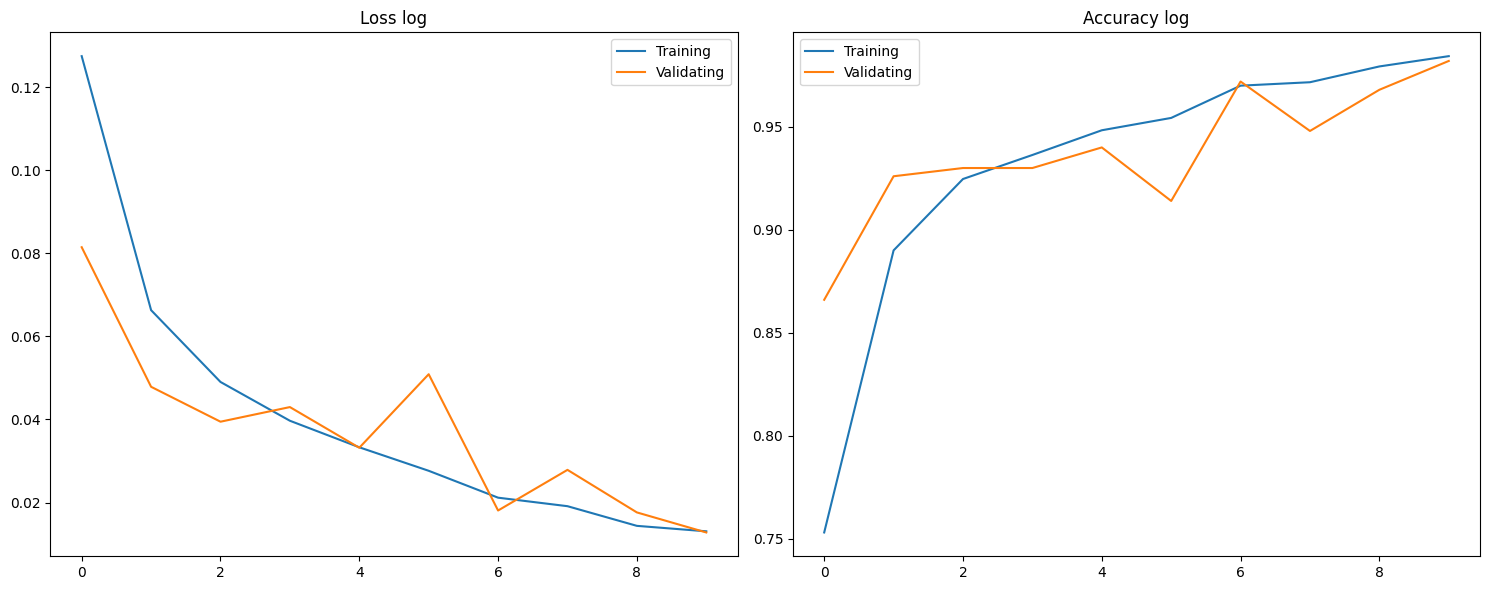

In [21]:
best_model = deepcopy(model)
best_acc = 0

train_loss = []
train_acc = []
val_loss = []
val_acc = []

for i in range(1, EPOCHS+1):
    model.train()

    diff = 0
    acc = 0
    total = 0

    for data, target in train_dl:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            data, target = data.to(device), target.to(device)
        # print(data.shape)
        out = model(data)
        out = out.to(torch.float32)
        loss = criterion(out.to(torch.float32), target)
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)

        loss.backward()
        optimizer.step()

    train_loss += [diff/total]
    train_acc += [acc/total]

    model.eval()

    diff = 0
    acc = 0
    total = 0

    with torch.no_grad():
        for data, target in val_dl:
            optimizer.zero_grad()
            if torch.cuda.is_available():
                data, target = data.to(device), target.to(device)

            out = model(data)
            out = out.to(torch.float32)
            loss = criterion(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss += [diff/total]
    val_acc += [acc/total]

    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        best_model = deepcopy(model)

    scheduler.step()

    print("Epoch {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1], train_acc[-1],
                                                                   val_loss[-1], val_acc[-1]))

fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

index = 0

axes[index].plot(train_loss, label="Training")
axes[index].plot(val_loss, label="Validating")
axes[index].set_title("Loss log")
axes[index].legend()

index += 1

axes[index].plot(train_acc, label="Training")
axes[index].plot(val_acc, label="Validating")
axes[index].set_title("Accuracy log")
axes[index].legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       237
           1       0.98      0.98      0.98       263

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



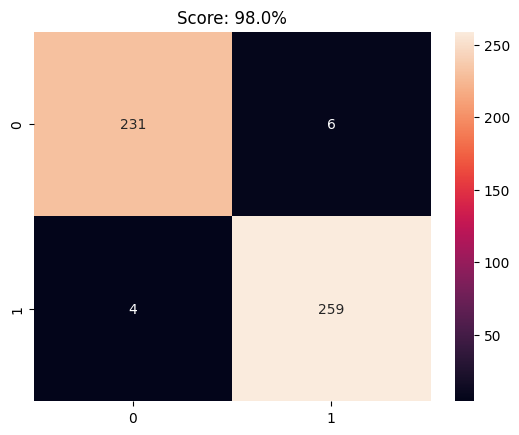

In [26]:
truth = []
preds = []

best_model.eval()

with torch.no_grad():
    for data, target in test_dl:
        if torch.cuda.is_available():
            data, target = data.to(device), target.to(device)
        out = best_model(data)
        out = F.softmax(out, dim=1)
        out = out.argmax(1)
        out = out.cpu().detach().numpy().tolist()
        preds += out
        truth += target.cpu().detach().numpy().tolist()

score = accuracy_score(preds, truth)
print(classification_report(preds, truth))
sns.heatmap(confusion_matrix(preds, truth), annot=True, fmt='d')
plt.title("Score: {}%".format(round(score*100, 2)))
plt.show()

In [27]:
import json

# unwrap DataParallel if it was used, so the saved keys don't have a "module." prefix
model_to_save = best_model.module if isinstance(best_model, nn.DataParallel) else best_model

torch.save(model_to_save.state_dict(), "best_ast_infant_cry.pth")

# Save the architecture config alongside the weights — critical, since you've been
# tuning r, num_layers, out_dim, etc. and need to reconstruct the exact same shapes later

config = {
    "label_dim": 527,
    "fstride": 10,
    "tstride": 10,
    "input_fdim": 128,
    "input_tdim": 1024,
    "imagenet_pretrain": True,
    "audioset_pretrain": True,
    "model_size": "base384"
}
with open("best_ast_infant_cry_config.json", "w") as f:
    json.dump(config, f, indent=2)


audio_conf = {'num_mel_bins': 128, 'target_length': 1024, 'freqm': 24, 'timem': 192, 'mixup': 0.5, 'skip_norm': False, 'mode': 'train', 'dataset': 'audioset', 'noise': False,
             'mean': -0.005844594683952334, 'std': 0.12848169072607715}

with open("ast_dataloader_conf.json", "w") as f:
    json.dump(audio_conf, f, indent=2)